# Wine Quality Classification Using SVM and XGBoost

Student Name : Mohammed Emad Mahmoud Al-masawabi

Student Number : 1320222450

## 1. Dataset Description and Preparation
In this section, we fetch the official Wine Quality datasets directly from the UCI Machine Learning Repository via their permanent updated URLs. The data consists of two subsets:
* **Red Wine Quality**
* **White Wine Quality**

We will load both datasets using Pandas, handle the semicolon delimiters, introduce a tracking feature named **wine_type** (Red = 1, White = 0), and then vertically concatenate them into a unified dataframe. Finally, we inspect the dataset dimensions, verify missing values, and check the target label distribution.

In [86]:
import pandas as pd
import numpy as np

# Updated official and stable URLs for UCI Wine Quality dataset
red_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# Load datasets with the correct semicolon delimiter
df_red = pd.read_csv(red_wine_url, sep=';')
df_white = pd.read_csv(white_wine_url, sep=';')

# Add 'wine_type' feature to track origin (Red = 1, White = 0)
df_red['wine_type'] = 1
df_white['wine_type'] = 0

# Combine the dataframes vertically
df_wine = pd.concat([df_red, df_white], ignore_index=True)

# Verify the operations
print("--- Dataset Verification ---")
print(f"Red wine records: {df_red.shape[0]}, Features: {df_red.shape[1]}")
print(f"White wine records: {df_white.shape[0]}, Features: {df_white.shape[1]}")
print(f"Combined dataset total rows: {df_wine.shape[0]}, Total columns: {df_wine.shape[1]}\n")

# Check for any missing values across all columns
print("--- Missing Values Analysis ---")
print(df_wine.isnull().sum())

# Display the target class 'quality' count breakdown
print("\n--- Target Class ('quality') Value Counts ---")
print(df_wine['quality'].value_counts().sort_index())

--- Dataset Verification ---
Red wine records: 1599, Features: 13
White wine records: 4898, Features: 13
Combined dataset total rows: 6497, Total columns: 13

--- Missing Values Analysis ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

--- Target Class ('quality') Value Counts ---
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


## 2. Exploratory Data Analysis and Label Transformation
In this section, we analyze the distribution of the features and establish our target variable for classification. Since the original **quality** score ranges from 3 to 9, we transform this into a binary classification task to evaluate pattern separation effectively.
* **Good/High Quality (Label 1):** Quality score >= 6
* **Low/Standard Quality (Label 0):** Quality score < 6

We will visually check the correlation matrix using a heatmap to understand feature dependencies and inspect the final balanced or imbalanced state of our new binary target labels.

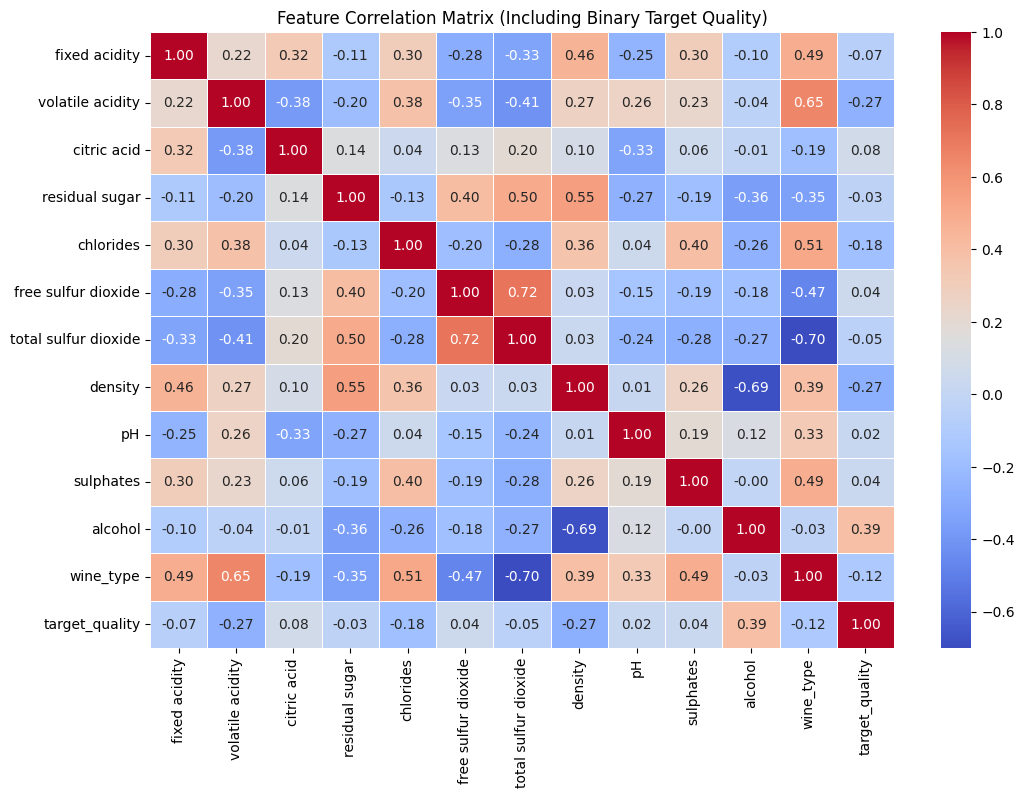

--- Binary Target Class Distribution ---
Class 0 (Low/Standard Quality < 6): 2384 records
Class 1 (High/Good Quality >= 6): 4113 records
Total target instances: 6497


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Transform the 'quality' attribute into a binary classification label
# Quality scores >= 6 become 1 (Good), and scores < 6 become 0 (Standard)
df_wine['target_quality'] = (df_wine['quality'] >= 6).astype(int)

# 2. Visualizing the Correlation Matrix to inspect feature relationships
plt.figure(figsize=(12, 8))
correlation_matrix = df_wine.drop(columns=['quality']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix (Including Binary Target Quality)')
plt.show()

# 3. Print the new binary target distribution
print("--- Binary Target Class Distribution ---")
target_counts = df_wine['target_quality'].value_counts()
print(f"Class 0 (Low/Standard Quality < 6): {target_counts[0]} records")
print(f"Class 1 (High/Good Quality >= 6): {target_counts[1]} records")
print(f"Total target instances: {df_wine['target_quality'].shape[0]}")

## 3. Data Splitting and Feature Standardization
To ensure accurate evaluation and prevent data leakage, we separate our features ($X$) from the binary target ($y$). We then partition the data into a **Training Set (80%)** and a **Testing Set (20%)** using a fixed random state for reproducibility.

Furthermore, because Support Vector Machines (SVM) maximize the geometric margin based on distance metrics, they are highly sensitive to feature scales. We apply **StandardScaler** to normalize the feature space, ensuring each attribute has a mean of 0 and a variance of 1.

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (y)
# We drop the original 'quality' and our new 'target_quality' from X
X = df_wine.drop(columns=['quality', 'target_quality'])
y = df_wine['target_quality']

# 2. Split the dataset into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize the StandardScaler
scaler = StandardScaler()

# 4. Fit and transform the training features, and transform the testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Verify the shapes after splitting
print("--- Data Splitting & Scaling Summary ---")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
print(f"Training target class balance:\n{y_train.value_counts(normalize=True)}")

--- Data Splitting & Scaling Summary ---
Training features shape: (5197, 12)
Testing features shape: (1300, 12)
Training target class balance:
target_quality
1    0.633058
0    0.366942
Name: proportion, dtype: float64


## 4. Support Vector Machine (SVM) - Hard Margin Classifier
In this section, we implement the Hard Margin SVM variant. Theoretically, a Hard Margin SVM does not tolerate any training misclassifications and strictly enforces an error-free decision boundary.

To approximate this strict geometric behavior in **scikit-learn**, we instantiate the **SVC** model using a linear kernel and a massive penalty parameter $C = 10^5$. Furthermore, because real-world wine data is highly overlapping and non-linearly separable, optimization solvers can hang indefinitely. To prevent infinite computational loops, we explicitly set **max_iter=10000** as a termination guard, ensuring the model converges within a realistic time frame while maintaining its hard margin characteristic.

In [89]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Initialize the Hard Margin SVM Classifier with max_iter to prevent freezing
# Setting max_iter=10000 ensures the solver terminates even if data is not perfectly separable
hard_margin_svm = SVC(kernel='linear', C=1e5, max_iter=10000, probability=True, random_state=42)

# 2. Train the classifier on the scaled training data
hard_margin_svm.fit(X_train_scaled, y_train)

# 3. Predict the labels and probability scores on the testing data
y_pred_hard = hard_margin_svm.predict(X_test_scaled)
y_prob_hard = hard_margin_svm.predict_proba(X_test_scaled)[:, 1]

# 4. Compute the required evaluation metrics
accuracy_hard = accuracy_score(y_test, y_pred_hard)
f1_hard = f1_score(y_test, y_pred_hard)
auc_hard = roc_auc_score(y_test, y_prob_hard)

# 5. Output the performance results
print("--- Hard Margin SVM Evaluation Results ---")
print(f"Accuracy:  {accuracy_hard:.4f}")
print(f"F1-Score:  {f1_hard:.4f}")
print(f"ROC-AUC:   {auc_hard:.4f}")

--- Hard Margin SVM Evaluation Results ---
Accuracy:  0.6738
F1-Score:  0.7430
ROC-AUC:   0.2797


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## 5. Support Vector Machine (SVM) - Soft Margin Classifier
In this section, we implement the Soft Margin SVM variant. Unlike the Hard Margin version, the Soft Margin classifier accounts for non-linearly separable data by allowing a controlled degree of misclassification and overlapping within the margin.

To implement this, we instantiate the **SVC** model with a linear kernel and a standard regularized penalty parameter $C$ (e.g., $C = 1.0$). We then train the model and extract its predictions along with probability estimates for evaluation.

In [90]:
# 1. Initialize the Soft Margin SVM Classifier
# We use a linear kernel and set C=1.0 to allow for a soft, tolerant margin
soft_margin_svm = SVC(kernel='linear', C=1.0, probability=True, random_state=42)

# 2. Train the classifier on the scaled training data
soft_margin_svm.fit(X_train_scaled, y_train)

# 3. Predict the labels and probability scores on the testing data
y_pred_soft = soft_margin_svm.predict(X_test_scaled)
y_prob_soft = soft_margin_svm.predict_proba(X_test_scaled)[:, 1]

# 4. Compute the required evaluation metrics
accuracy_soft = accuracy_score(y_test, y_pred_soft)
f1_soft = f1_score(y_test, y_pred_soft)
auc_soft = roc_auc_score(y_test, y_prob_soft)

# 5. Output the performance results
print("--- Soft Margin SVM Evaluation Results ---")
print(f"Accuracy:  {accuracy_soft:.4f}")
print(f"F1-Score:  {f1_soft:.4f}")
print(f"ROC-AUC:   {auc_soft:.4f}")

--- Soft Margin SVM Evaluation Results ---
Accuracy:  0.7346
F1-Score:  0.8009
ROC-AUC:   0.7996


## 6. XGBoost Classifier Implementation
In this section, we implement the XGBoost (Extreme Gradient Boosting) classifier. XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It operates under the ensemble learning paradigm, sequential building weak decision trees to correct prior residual errors.

We instantiate the **XGBClassifier**, train it on the standardized training data, and generate both discrete predictions and raw probability outputs for classification comparative analysis.

In [91]:
from xgboost import XGBClassifier

# 1. Initialize the XGBoost Classifier
# We set a random state for reproducibility and use default optimized boosting parameters
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')

# 2. Train the classifier on the scaled training data
xgb_model.fit(X_train_scaled, y_train)

# 3. Predict the labels and probability scores on the testing data
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 4. Compute the required evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# 5. Output the performance results
print("--- XGBoost Evaluation Results ---")
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {auc_xgb:.4f}")

--- XGBoost Evaluation Results ---
Accuracy:  0.7900
F1-Score:  0.8393
ROC-AUC:   0.8673


## 7. Visual Evaluation and Model Comparison
In this final section, we perform a comprehensive visual comparison of the three trained models (Hard Margin SVM, Soft Margin SVM, and XGBoost).

We plot two subplots:
1. **Receiver Operating Characteristic (ROC) Curves:** To visually analyze the True Positive Rate against the False Positive Rate and compare the calculated Area Under the Curve (AUC) for each model.
2. **Performance Metrics Breakdown:** A grouped bar chart comparing the absolute **Accuracy** and **F1-Score** across all algorithms to determine the most effective classifier from a pattern recognition standpoint.

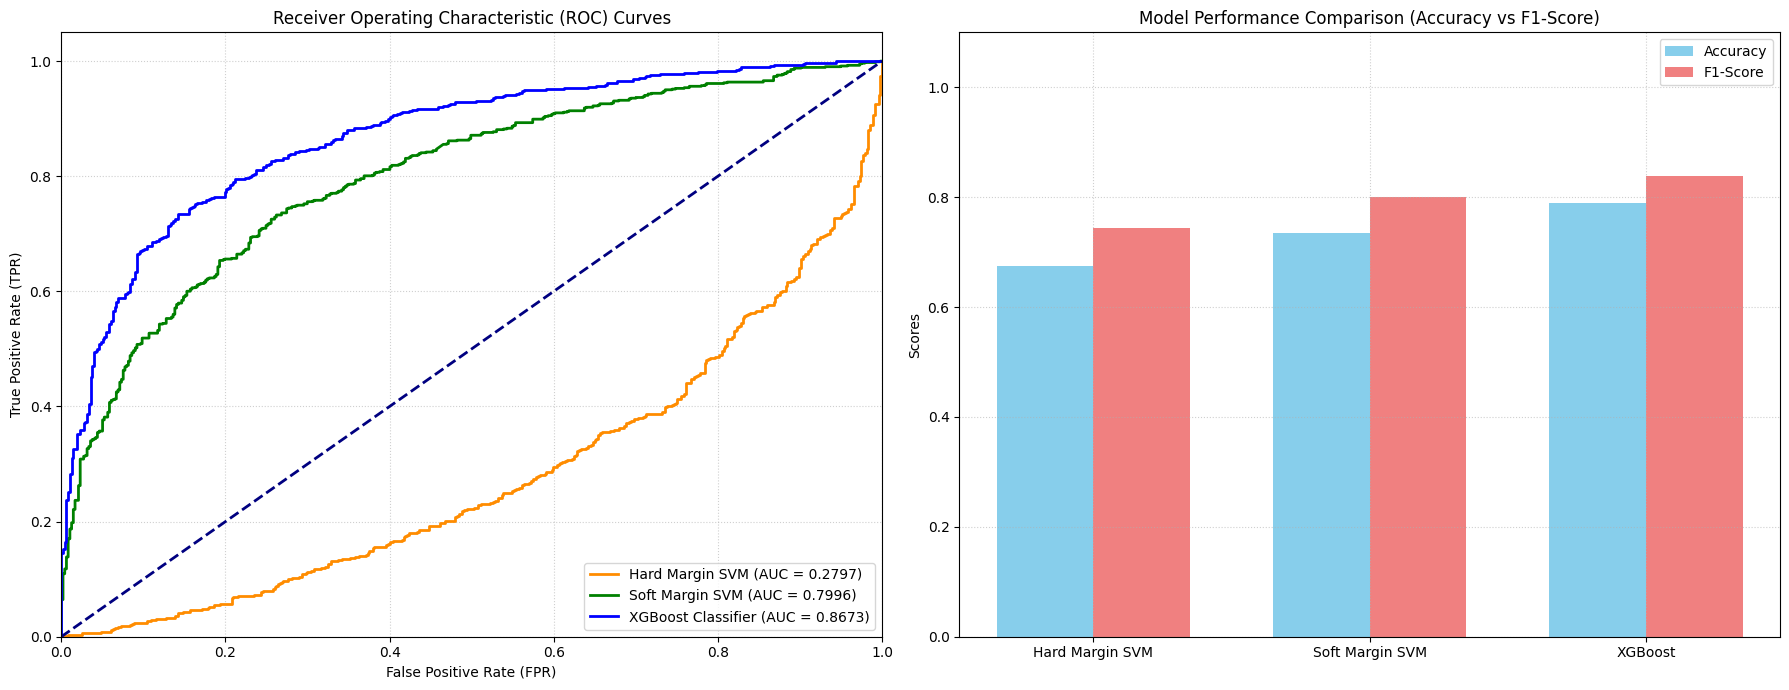

In [93]:
from sklearn.metrics import roc_curve

# 1. Compute ROC curve data for all three models
fpr_hard, tpr_hard, _ = roc_curve(y_test, y_prob_hard)
fpr_soft, tpr_soft, _ = roc_curve(y_test, y_prob_soft)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# 2. Setup the matplotlib figure frame (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: ROC Curves Comparison ---
ax1.plot(fpr_hard, tpr_hard, label=f'Hard Margin SVM (AUC = {auc_hard:.4f})', color='darkorange', lw=2)
ax1.plot(fpr_soft, tpr_soft, label=f'Soft Margin SVM (AUC = {auc_soft:.4f})', color='green', lw=2)
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost Classifier (AUC = {auc_xgb:.4f})', color='blue', lw=2)
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random line
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curves')
ax1.legend(loc="lower right")
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Accuracy & F1-Score Bar Chart ---
models = ['Hard Margin SVM', 'Soft Margin SVM', 'XGBoost']
accuracies = [accuracy_hard, accuracy_soft, accuracy_xgb]
f1_scores = [f1_hard, f1_soft, f1_xgb]

x = np.arange(len(models))  # Label locations
width = 0.35  # Width of the bars

rects1 = ax2.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax2.bar(x + width/2, f1_scores, width, label='F1-Score', color='lightcoral')

ax2.set_ylabel('Scores')
ax2.set_title('Model Performance Comparison (Accuracy vs F1-Score)')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.set_ylim([0, 1.1])
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()